In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
# cutoff_list = {'P2_Y54.dat':5, 
#           'P2_N53.dat':5, 
#           'P-1_N53.dat':5, 
#           'P-1_P51.dat':6, 
#           'L-7CB_L49.dat':6, 
#           'K-3CG_L49.dat':7, 
#           'K-3CD_A13.dat':7, 
#           'P0_Y10.dat':7}
cutoff = 6

# ArkA12 Bound sims

In [4]:
hydro_distances_bound = []
hydro_mean_bound = {}
hydro_percent_bound = {}
import glob, os
os.chdir('/data/kball/SH3_binding/salt_paper_analysis/AbpSH3_ArkA12/distances')
hydro_distances_bound = glob.glob('*.dat')
hydro_distances_bound

['P2_Y54.dat',
 'P2_N53.dat',
 'P-1_N53.dat',
 'P-1_P51.dat',
 'L-7CB_L49.dat',
 'K-3CG_L49.dat',
 'K-3CD_A13.dat',
 'P0_Y10.dat',
 'K3_Y8.dat',
 'P0_P51.dat',
 'P-1_D35.dat',
 'K-3_W36.dat']

In [5]:
num_bound_sims = 10
num_bound_snapshots = int(len(pd.read_table(hydro_distances_bound[0], sep = '\s+'))/num_bound_sims)

hydro_std_bound = {}

for i in hydro_distances_bound:
    df = pd.read_table(i, sep = '\s+')
    hydro_mean_bound[i] = np.mean(df.iloc[:,1])
    hydro_percent_bound[i] = (df.iloc[:,1] < cutoff).mean()
    
    prct_bnd_by_sim = pd.DataFrame(columns=[0])
    for sim in range(0,num_bound_sims):
        prct_bnd_by_sim.loc[0,sim] = (df.iloc[sim*num_bound_snapshots:(sim+1)*num_bound_snapshots, 1] < cutoff).mean()
    hydro_std_bound[i] = prct_bnd_by_sim.std(axis=1).iloc[0]
    if i == 'P2_Y54.dat':
        P2_Y54_prct_bnd = df.iloc[:,1] < cutoff
#    print(i)
#    print(prct_bnd_by_sim)
    
hydro_percent_bound

{'P2_Y54.dat': 0.7985020833333333,
 'P2_N53.dat': 0.9117658333333334,
 'P-1_N53.dat': 0.7607016666666667,
 'P-1_P51.dat': 0.9125683333333333,
 'L-7CB_L49.dat': 0.77076875,
 'K-3CG_L49.dat': 0.27189875,
 'K-3CD_A13.dat': 0.02560125,
 'P0_Y10.dat': 0.6436329166666667,
 'K3_Y8.dat': 0.984165,
 'P0_P51.dat': 0.979215,
 'P-1_D35.dat': 0.9948225,
 'K-3_W36.dat': 0.9742220833333334}

In [6]:
P2_Y54_prct_bnd

0           True
1           True
2           True
3           True
4           True
           ...  
2399995     True
2399996     True
2399997    False
2399998     True
2399999     True
Name: Dis_00001, Length: 2400000, dtype: bool

In [7]:
hydro_std_bound

{'P2_Y54.dat': 0.032254777929277036,
 'P2_N53.dat': 0.018994145946762495,
 'P-1_N53.dat': 0.06051632075673552,
 'P-1_P51.dat': 0.030417507865080295,
 'L-7CB_L49.dat': 0.12049506867518928,
 'K-3CG_L49.dat': 0.03418892364776788,
 'K-3CD_A13.dat': 0.008929085123890988,
 'P0_Y10.dat': 0.049562036955086375,
 'K3_Y8.dat': 0.011840129634133514,
 'P0_P51.dat': 0.013693424460550026,
 'P-1_D35.dat': 0.0043431464741931275,
 'K-3_W36.dat': 0.015148374455686373}

In [8]:
hydro_distances_ArkA12binding = []
import glob, os
os.chdir('/data/kball/SH3_binding/binding_paper_analysis/hydrophobics/ArkA12_binding/distances')
hydro_distances_ArkA12binding = glob.glob('*.dat')
hydro_distances_ArkA12binding

['P2_Y54.dat',
 'P2_N53.dat',
 'P-1_N53.dat',
 'P-1_P51.dat',
 'L-7CB_L49.dat',
 'K-3CG_L49.dat',
 'K-3CD_A13.dat',
 'P0_Y10.dat',
 'K3_Y8.dat',
 'P0_P51.dat',
 'P-1_D35.dat',
 'K-3_W36.dat']

In [9]:
arka12_stat = pd.read_csv('/data/kball/SH3_binding/binding_paper_analysis/ArkA12_status.csv')

In [10]:
arka12_stat['status'].unique()

array(['unbound', 'partial', 'Fwd', 'seg2 only', 'Bound', 'Rev'],
      dtype=object)

In [11]:
num_ArkA12binding_sims = 50
num_ArkA12_snap = int(len(pd.read_table(hydro_distances_ArkA12binding[0], sep = '\s+'))/num_ArkA12binding_sims)

hydro_std_ArkA12binding = {}
encounter_hydro_std_ArkA12 = {}

hydro_mean_ArkA12binding = {}
hydro_percent_ArkA12binding = {}
encounter_hydro_percent_ArkA12 = {}

for i in hydro_distances_ArkA12binding:
    df = pd.read_table(i, sep = '\s+')
    df['status'] = arka12_stat['status']
    hydro_mean_ArkA12binding[i] = np.mean(df[df.columns[1]])
    hydro_percent_ArkA12binding[i] = np.mean(df[df.columns[1]] < cutoff)
    encounter_hydro_percent_ArkA12[i] = np.mean((df[df.columns[1]] < cutoff) & (df['status'] != 'unbound') & 
                                            (df['status'] != 'Bound')) / np.mean((df['status'] != 'unbound') & 
                                            (df['status'] != 'Bound'))
    
    prct_ArkA12binding_by_sim = pd.DataFrame(columns=[0])
    prct_encounter_by_sim = pd.DataFrame(columns=[0])    
    for sim in range(0,num_ArkA12binding_sims):
        prct_ArkA12binding_by_sim.loc[0,sim] = (df.iloc[sim*num_ArkA12_snap:(sim+1)*num_ArkA12_snap, 1] < cutoff).mean()
        
        by_sim = df[sim*num_ArkA12_snap:(sim+1)*num_ArkA12_snap]
        
        encounter_status_sim = by_sim[(by_sim['status'] != 'unbound') & (by_sim['status'] != 'Bound')]
        prct_encounter_by_sim.loc[0,sim] = (encounter_status_sim.iloc[:,1] < cutoff).mean()    
        
#    print(i)
#    print(prct_rev_by_sim)
    
    hydro_std_ArkA12binding[i] = prct_ArkA12binding_by_sim.sem(axis=1).iloc[0]

    encounter_hydro_std_ArkA12[i] = prct_encounter_by_sim.sem(axis=1).iloc[0]

In [12]:
hydro_percent_ArkA12binding

{'P2_Y54.dat': 0.1155098,
 'P2_N53.dat': 0.1195192,
 'P-1_N53.dat': 0.1564644,
 'P-1_P51.dat': 0.1237744,
 'L-7CB_L49.dat': 0.1616288,
 'K-3CG_L49.dat': 0.0477238,
 'K-3CD_A13.dat': 0.047208,
 'P0_Y10.dat': 0.1044676,
 'K3_Y8.dat': 0.138423,
 'P0_P51.dat': 0.1414414,
 'P-1_D35.dat': 0.1261654,
 'K-3_W36.dat': 0.1987894}

In [13]:
hydro_std_ArkA12binding

{'P2_Y54.dat': 0.03077037265928088,
 'P2_N53.dat': 0.03458410582893446,
 'P-1_N53.dat': 0.028928642362043545,
 'P-1_P51.dat': 0.037265388446850976,
 'L-7CB_L49.dat': 0.03505093695756599,
 'K-3CG_L49.dat': 0.011365699608156867,
 'K-3CD_A13.dat': 0.0101147734749217,
 'P0_Y10.dat': 0.02888600503677325,
 'K3_Y8.dat': 0.040665898703047626,
 'P0_P51.dat': 0.038737398947597215,
 'P-1_D35.dat': 0.037791773210375953,
 'K-3_W36.dat': 0.03785831604048474}

In [14]:

hydro_contacts = pd.DataFrame.from_dict(hydro_percent_bound, orient='index', columns=['ArkA12 bound simulations'])
hydro_contacts['ArkA12 binding simulations: encounter'] = pd.DataFrame.from_dict(encounter_hydro_percent_ArkA12, 
                                                                                  orient='index')

In [15]:
hydro_contacts = hydro_contacts.rename(index={"P-1_P51.dat": "P(-1) to P51", "L-7CB_L49.dat": "L(-7)CB to L49", 
                                              "K-3CD_A13.dat": "K(-3)CD to A13", "K-3CG_L49.dat": "K(-3)CG to L49",
                                              "P0_Y10.dat": "P(0) to Y10", "P2_N53.dat": "P(2) to N53", "P2_Y54.dat": "P(2) to Y54", 
                                              "P-1_N53.dat": "P(-1) to N53", "K3_Y8.dat": "K(3) to Y8", "P0_P51.dat": "P(0) to P51",
                                              "P-1_D35.dat": "P(-1) to D35", "K-3_W36.dat": "K(-3) to W36"})
hydro_contacts = hydro_contacts.reindex(["K(3) to Y8", "P(2) to N53", "P(2) to Y54", "P(0) to P51", "P(0) to Y10", "P(-1) to P51", 
                                         "P(-1) to D35", "P(-1) to N53", "K(-3) to W36",
                                         "K(-3)CD to A13", "K(-3)CG to L49", "L(-7)CB to L49"])

In [16]:

hydro_contacts_std = pd.DataFrame.from_dict(hydro_std_bound, orient='index', columns=['ArkA12 bound simulations'])
hydro_contacts_std['ArkA12 binding simulations: encounter'] = pd.DataFrame.from_dict(encounter_hydro_std_ArkA12, 
                                                                                  orient='index')

hydro_contacts_std = hydro_contacts_std.rename(index={"P-1_P51.dat": "P(-1) to P51", "L-7CB_L49.dat": "L(-7)CB to L49", 
                                              "K-3CD_A13.dat": "K(-3)CD to A13", "K-3CG_L49.dat": "K(-3)CG to L49",
                                              "P0_Y10.dat": "P(0) to Y10", "P2_N53.dat": "P(2) to N53", "P2_Y54.dat": "P(2) to Y54", 
                                              "P-1_N53.dat": "P(-1) to N53", "K3_Y8.dat": "K(3) to Y8", "P0_P51.dat": "P(0) to P51",
                                              "P-1_D35.dat": "P(-1) to D35", "K-3_W36.dat": "K(-3) to W36"})
hydro_contacts_std = hydro_contacts_std.reindex(["K(3) to Y8", "P(2) to N53", "P(2) to Y54", "P(0) to P51", "P(0) to Y10", "P(-1) to P51", 
                                         "P(-1) to D35", "P(-1) to N53", "K(-3) to W36",
                                         "K(-3)CD to A13", "K(-3)CG to L49", "L(-7)CB to L49"])

In [17]:
hydro_contacts

,ArkA12 bound simulations,ArkA12 binding simulations: encounter
K(3) to Y8,0.984165,0.028002
P(2) to N53,0.911766,0.023939
P(2) to Y54,0.798502,0.028472
P(0) to P51,0.979215,0.041443
P(0) to Y10,0.643633,0.043211
P(-1) to P51,0.912568,0.026370
P(-1) to D35,0.994823,0.019225
P(-1) to N53,0.760702,0.092257
K(-3) to W36,0.974222,0.114062
K(-3)CD to A13,0.025601,0.052674


In [18]:
hydro_contacts_std

,ArkA12 bound simulations,ArkA12 binding simulations: encounter
K(3) to Y8,0.011840,0.021261
P(2) to N53,0.018994,0.014406
P(2) to Y54,0.032255,0.017600
P(0) to P51,0.013693,0.016396
P(0) to Y10,0.049562,0.022490
P(-1) to P51,0.030418,0.018004
P(-1) to D35,0.004343,0.009044
P(-1) to N53,0.060516,0.018243
K(-3) to W36,0.015148,0.020891
K(-3)CD to A13,0.008929,0.012383


In [19]:
hydro_contacts_important = hydro_contacts.drop(['P(0) to Y10', 'P(-1) to N53', 'K(-3)CD to A13', 'K(-3)CG to L49'])
hydro_contacts_std_important = hydro_contacts_std.drop(['P(0) to Y10', 'P(-1) to N53', 'K(-3)CD to A13', 'K(-3)CG to L49'])

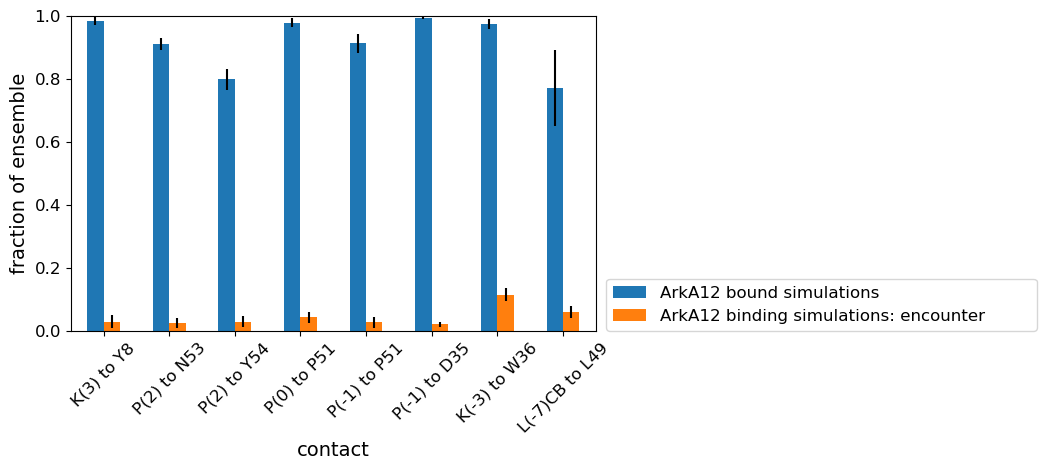

In [20]:
#plt.figure(figsize=(10,5))
ax1 = hydro_contacts_important.plot(kind='bar', yerr=hydro_contacts_std_important, fontsize = 12)
ax1.set_ylim(0,1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, size = 12)
ax1.set_ylabel("fraction of ensemble", size = 14)
ax1.set_xlabel("contact", size = 14)
ax1.legend(bbox_to_anchor=(1.02, 0., 0.82, 1.), loc='lower left',
           ncol=1, mode="expand", borderaxespad=0., fontsize = 12)
plt.tight_layout()
#plt.savefig('/data/kball/SH3_binding/binding_paper_analysis/hydrophobics/Arka12_hydrophobics.pdf', dpi=1000, bbox_inches='tight')

# Do the same for salt simulations

# ArkA12 Bound sims

In [21]:
salt_hydro_distances_bound = []
salt_hydro_mean_bound = {}
salt_hydro_percent_bound = {}
import glob, os
os.chdir('/data/kball/SH3_binding/salt_paper_analysis/AbpSH3_ArkA12_NaCl/distances')
salt_hydro_distances_bound = glob.glob('*.dat')
salt_hydro_distances_bound

['P2_Y54.dat',
 'P2_N53.dat',
 'P-1_N53.dat',
 'P-1_P51.dat',
 'L-7CB_L49.dat',
 'K-3CG_L49.dat',
 'K-3CD_A13.dat',
 'P0_Y10.dat',
 'K3_Y8.dat',
 'P0_P51.dat',
 'P-1_D35.dat',
 'K-3_W36.dat']

In [22]:
num_bound_sims = 10
num_bound_snapshots = int(len(pd.read_table(salt_hydro_distances_bound[0], sep = '\s+'))/num_bound_sims)

salt_hydro_std_bound = {}

for i in salt_hydro_distances_bound:
    df = pd.read_table(i, sep = '\s+')
    salt_hydro_mean_bound[i] = np.mean(df.iloc[:,1])
    salt_hydro_percent_bound[i] = (df.iloc[:,1] < cutoff).mean()
    
    prct_bnd_by_sim = pd.DataFrame(columns=[0])
    for sim in range(0,num_bound_sims):
        prct_bnd_by_sim.loc[0,sim] = (df.iloc[sim*num_bound_snapshots:(sim+1)*num_bound_snapshots, 1] < cutoff).mean()
    salt_hydro_std_bound[i] = prct_bnd_by_sim.std(axis=1).iloc[0]
    if i == 'P2_Y54.dat':
        P2_Y54_prct_bnd_salt = df.iloc[:,1] < cutoff
#    print(i)
#    print(prct_bnd_by_sim)
    
salt_hydro_percent_bound

{'P2_Y54.dat': 0.87612125,
 'P2_N53.dat': 0.9256420833333333,
 'P-1_N53.dat': 0.8134225,
 'P-1_P51.dat': 0.9457166666666666,
 'L-7CB_L49.dat': 0.7477458333333333,
 'K-3CG_L49.dat': 0.2233625,
 'K-3CD_A13.dat': 0.028884583333333335,
 'P0_Y10.dat': 0.5722166666666667,
 'K3_Y8.dat': 0.96913625,
 'P0_P51.dat': 0.97295875,
 'P-1_D35.dat': 0.9961791666666666,
 'K-3_W36.dat': 0.9698333333333333}

In [23]:
P2_Y54_prct_bnd_salt

0          True
1          True
2          True
3          True
4          True
           ... 
2399995    True
2399996    True
2399997    True
2399998    True
2399999    True
Name: Dis_00001, Length: 2400000, dtype: bool

In [24]:
salt_hydro_distances_ArkA12binding = []
import glob, os
os.chdir('/data/kball/SH3_binding/salt_paper_analysis/ArkA12_binding_NaCl/distances')
salt_hydro_distances_ArkA12binding = glob.glob('*.dat')
salt_hydro_distances_ArkA12binding

['P2_Y54.dat',
 'P2_N53.dat',
 'P-1_N53.dat',
 'P-1_P51.dat',
 'L-7CB_L49.dat',
 'K-3CG_L49.dat',
 'K-3CD_A13.dat',
 'P0_Y10.dat',
 'K3_Y8.dat',
 'P0_P51.dat',
 'P-1_D35.dat',
 'K-3_W36.dat']

In [25]:
arka12_stat = pd.read_csv('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/status_files/ArkA12_binding_salt_status.csv')

In [26]:
num_ArkA12binding_sims = 50
num_ArkA12_snap = int(len(pd.read_table(salt_hydro_distances_ArkA12binding[0], sep = '\s+'))/num_ArkA12binding_sims)

salt_hydro_std_ArkA12binding = {}
encounter_salt_hydro_std_ArkA12 = {}

salt_hydro_mean_ArkA12binding = {}
salt_hydro_percent_ArkA12binding = {}
encounter_salt_hydro_percent_ArkA12 = {}

for i in salt_hydro_distances_ArkA12binding:
    df = pd.read_table(i, sep = '\s+')
    df['status'] = arka12_stat['status']
    salt_hydro_mean_ArkA12binding[i] = np.mean(df[df.columns[1]])
    salt_hydro_percent_ArkA12binding[i] = np.mean(df[df.columns[1]] < cutoff)
    encounter_salt_hydro_percent_ArkA12[i] = np.mean((df[df.columns[1]] < cutoff) & (df['status'] != 'unbound') & 
                                            (df['status'] != 'Bound')) / np.mean((df['status'] != 'unbound') & 
                                            (df['status'] != 'Bound'))
    prct_ArkA12binding_by_sim = pd.DataFrame(columns=[0])
    prct_encounter_by_sim = pd.DataFrame(columns=[0])    
    for sim in range(0,num_ArkA12binding_sims):
        prct_ArkA12binding_by_sim.loc[0,sim] = (df.iloc[sim*num_ArkA12_snap:(sim+1)*num_ArkA12_snap, 1] < cutoff).mean()
        
        by_sim = df[sim*num_ArkA12_snap:(sim+1)*num_ArkA12_snap]
        
        encounter_status_sim = by_sim[(by_sim['status'] != 'unbound') & (by_sim['status'] != 'Bound')]
        prct_encounter_by_sim.loc[0,sim] = (encounter_status_sim.iloc[:,1] < cutoff).mean()
        
#    print(i)
#    print(prct_rev_by_sim)
    
    salt_hydro_std_ArkA12binding[i] = prct_ArkA12binding_by_sim.sem(axis=1).iloc[0]
    
    encounter_salt_hydro_std_ArkA12[i] = prct_encounter_by_sim.sem(axis=1).iloc[0]

In [27]:

salt_hydro_contacts = pd.DataFrame.from_dict(salt_hydro_percent_bound, orient='index', columns=['ArkA12 bound simulations'])
salt_hydro_contacts['ArkA12 binding simulations: encounter'] = pd.DataFrame.from_dict(encounter_salt_hydro_percent_ArkA12, 
                                                                                  orient='index')

In [28]:
salt_hydro_contacts = salt_hydro_contacts.rename(index={"P-1_P51.dat": "P(-1) to P51", "L-7CB_L49.dat": "L(-7)CB to L49", 
                                              "K-3CD_A13.dat": "K(-3)CD to A13", "K-3CG_L49.dat": "K(-3)CG to L49",
                                              "P0_Y10.dat": "P(0) to Y10", "P2_N53.dat": "P(2) to N53", "P2_Y54.dat": "P(2) to Y54", 
                                              "P-1_N53.dat": "P(-1) to N53", "K3_Y8.dat": "K(3) to Y8", "P0_P51.dat": "P(0) to P51",
                                              "P-1_D35.dat": "P(-1) to D35", "K-3_W36.dat": "K(-3) to W36"})
salt_hydro_contacts = salt_hydro_contacts.reindex(["K(3) to Y8", "P(2) to N53", "P(2) to Y54", "P(0) to P51", "P(0) to Y10", "P(-1) to P51", 
                                         "P(-1) to D35", "P(-1) to N53", "K(-3) to W36",
                                         "K(-3)CD to A13", "K(-3)CG to L49", "L(-7)CB to L49"])

In [29]:

salt_hydro_contacts_std = pd.DataFrame.from_dict(salt_hydro_std_bound, orient='index', columns=['ArkA12 bound simulations'])
salt_hydro_contacts_std['ArkA12 binding simulations: encounter'] = pd.DataFrame.from_dict(encounter_salt_hydro_std_ArkA12, 
                                                                                  orient='index')

salt_hydro_contacts_std = salt_hydro_contacts_std.rename(index={"P-1_P51.dat": "P(-1) to P51", "L-7CB_L49.dat": "L(-7)CB to L49", 
                                              "K-3CD_A13.dat": "K(-3)CD to A13", "K-3CG_L49.dat": "K(-3)CG to L49",
                                              "P0_Y10.dat": "P(0) to Y10", "P2_N53.dat": "P(2) to N53", "P2_Y54.dat": "P(2) to Y54", 
                                              "P-1_N53.dat": "P(-1) to N53", "K3_Y8.dat": "K(3) to Y8", "P0_P51.dat": "P(0) to P51",
                                              "P-1_D35.dat": "P(-1) to D35", "K-3_W36.dat": "K(-3) to W36"})
salt_hydro_contacts_std = salt_hydro_contacts_std.reindex(["K(3) to Y8", "P(2) to N53", "P(2) to Y54", "P(0) to P51", "P(0) to Y10", "P(-1) to P51", 
                                         "P(-1) to D35", "P(-1) to N53", "K(-3) to W36",
                                         "K(-3)CD to A13", "K(-3)CG to L49", "L(-7)CB to L49"])

In [30]:
salt_hydro_contacts_important = salt_hydro_contacts.drop(['P(0) to Y10', 'P(-1) to N53', 'K(-3)CD to A13', 'K(-3)CG to L49'])
salt_hydro_contacts_std_important = salt_hydro_contacts_std.drop(['P(0) to Y10', 'P(-1) to N53', 'K(-3)CD to A13', 'K(-3)CG to L49'])

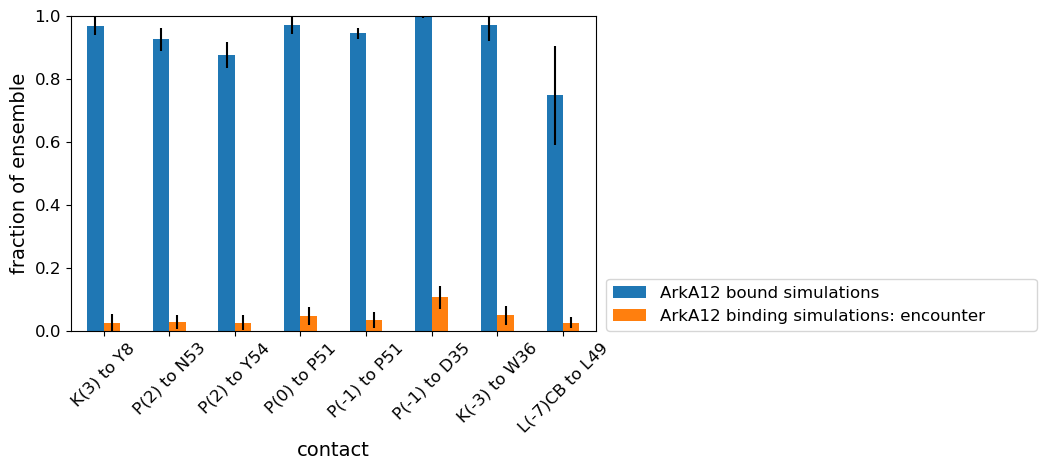

In [31]:
#plt.figure(figsize=(10,5))
ax1 = salt_hydro_contacts_important.plot(kind='bar', yerr=salt_hydro_contacts_std_important, fontsize = 12)
ax1.set_ylim(0,1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, size = 12)
ax1.set_ylabel("fraction of ensemble", size = 14)
ax1.set_xlabel("contact", size = 14)
ax1.legend(bbox_to_anchor=(1.02, 0., 0.82, 1.), loc='lower left',
           ncol=1, mode="expand", borderaxespad=0., fontsize = 12)
plt.tight_layout()

# No salt - salt

In [32]:
nosalt_minus_salt = hydro_contacts_important - salt_hydro_contacts_important
nosalt_minus_salt

,ArkA12 bound simulations,ArkA12 binding simulations: encounter
K(3) to Y8,0.015029,0.003856
P(2) to N53,-0.013876,-0.003749
P(2) to Y54,-0.077619,0.003997
P(0) to P51,0.006256,-0.005074
P(-1) to P51,-0.033148,-0.006817
P(-1) to D35,-0.001357,-0.085905
K(-3) to W36,0.004389,0.064868
L(-7)CB to L49,0.023023,0.033808


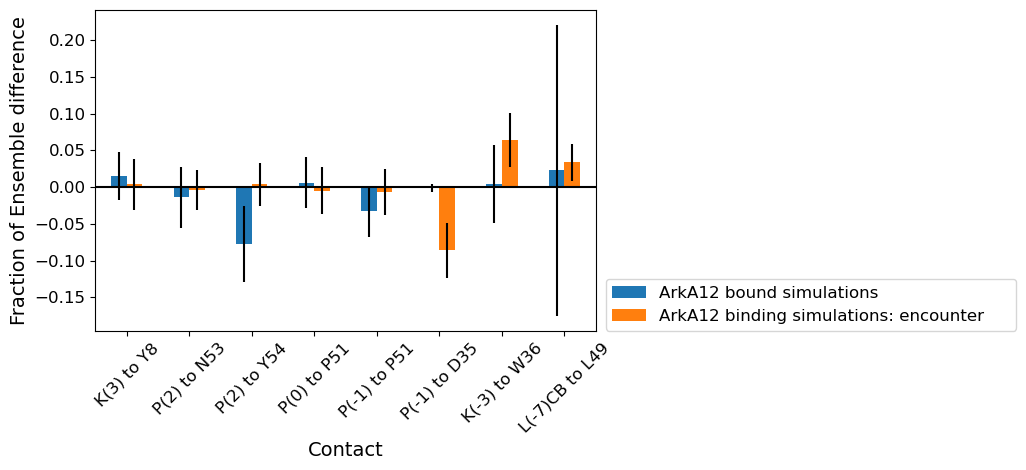

In [33]:
#plt.figure(figsize=(10,5))
ax1 = nosalt_minus_salt.plot(kind='bar', yerr=(hydro_contacts_std_important**2 + salt_hydro_contacts_std_important**2)**0.5, fontsize = 12)
#ax1.set_ylim(0,1)
plt.axhline(y=0, color='k', linestyle='-')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, size = 12)
ax1.set_ylabel("Fraction of Ensemble difference", size = 14)
ax1.set_xlabel("Contact", size = 14)
ax1.legend(bbox_to_anchor=(1.02, 0., 0.82, 1.), loc='lower left',
           ncol=1, mode="expand", borderaxespad=0., fontsize = 12)
plt.tight_layout()

In [34]:
salt_hydro_contacts_important

,ArkA12 bound simulations,ArkA12 binding simulations: encounter
K(3) to Y8,0.969136,0.024146
P(2) to N53,0.925642,0.027688
P(2) to Y54,0.876121,0.024475
P(0) to P51,0.972959,0.046517
P(-1) to P51,0.945717,0.033188
P(-1) to D35,0.996179,0.105131
K(-3) to W36,0.969833,0.049193
L(-7)CB to L49,0.747746,0.025232


Current dimensions: 15.0 x 9.0 inches
New dimensions: 4.5 x 2.6999999999999997 inches


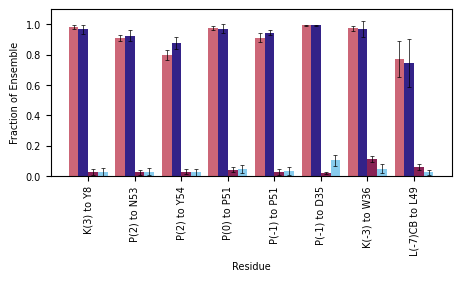

In [41]:
species = ("K(3) to Y8", "P(2) to N53", "P(2) to Y54", "P(0) to P51", "P(-1) to P51", 
                                         "P(-1) to D35", "K(-3) to W36",
                                         "L(-7)CB to L49")

colors = ['#CC6677', '#332288', '#882255', '#88CCEE']

penguin_means = {
    'Bound, no salt': hydro_contacts_important['ArkA12 bound simulations'],
    'Bound, salt': salt_hydro_contacts_important['ArkA12 bound simulations'],
    'Encounter, no salt': hydro_contacts_important['ArkA12 binding simulations: encounter'],
    'Encounter, salt': salt_hydro_contacts_important['ArkA12 binding simulations: encounter']
}

all_sems = {
    'Bound, no salt': hydro_contacts_std_important['ArkA12 bound simulations'],
    'Bound, salt': salt_hydro_contacts_std_important['ArkA12 bound simulations'],
    'Encounter, no salt': hydro_contacts_std_important['ArkA12 binding simulations: encounter'],
    'Encounter, salt': salt_hydro_contacts_std_important['ArkA12 binding simulations: encounter']
}

x = np.arange(len(species))*1.2  # the label locations
width = 0.25  # the width of the bars
multiplier = - width*2

fig, ax = plt.subplots(figsize=(15, 9), layout='constrained')

for i, (attribute, measurement) in enumerate(penguin_means.items()):
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, yerr=all_sems[attribute], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, label=attribute, color=colors[i])
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Fraction of Ensemble', fontsize=7)
ax.set_xlabel('Residue', fontsize=7)
ax.set_xticks(x + width, species, rotation=90, fontsize=7)
ax.tick_params(axis='y', labelsize=7)

#ax.legend(loc='upper left', ncols=3)
#ax.legend(frameon=False, bbox_to_anchor=(1.02, 0., 0.82, 1.), loc='lower left',
#           ncol=1, borderaxespad=0., fontsize = 7)
ax.set_ylim(0, 1.1)
#plt.figure(figsize=(15,5))

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 4.5

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('/data/mcohen3/SH3/notebooks/hydrophobic_ArkA12.png', dpi=1000, bbox_inches='tight')

plt.show()

In [36]:
hydro_contacts_important['ArkA12 binding simulations: encounter']

K(3) to Y8        0.028002
P(2) to N53       0.023939
P(2) to Y54       0.028472
P(0) to P51       0.041443
P(-1) to P51      0.026370
P(-1) to D35      0.019225
K(-3) to W36      0.114062
L(-7)CB to L49    0.059040
Name: ArkA12 binding simulations: encounter, dtype: float64

In [37]:
salt_hydro_contacts_important['ArkA12 binding simulations: encounter']

K(3) to Y8        0.024146
P(2) to N53       0.027688
P(2) to Y54       0.024475
P(0) to P51       0.046517
P(-1) to P51      0.033188
P(-1) to D35      0.105131
K(-3) to W36      0.049193
L(-7)CB to L49    0.025232
Name: ArkA12 binding simulations: encounter, dtype: float64

# Finding p-values

In [38]:
# ArkA12 bound, P(2) to Y54
ArkA12_avg_values = np.concatenate([P2_Y54_prct_bnd_salt, P2_Y54_prct_bnd])

#calculate the real difference, no salt minus salt
diff = nosalt_minus_salt.iloc[2,1]

print("ArkA12 bound, P(2) to Y54 800 mM NaCl vs no-salt difference = " , diff)


#sample 10000 times and calculate differences
numsample = 10000
num_bound_sims = 10
salt_num_bound_sims = 10
diff_samples = [0]*numsample
diff_samples_larger = [0]*numsample
for sample in range(0,len(diff_samples)):
    random_groups = np.random.permutation(ArkA12_avg_values)
    diff_samples[sample] = (np.mean(random_groups[0:num_bound_sims]) 
             - np.mean(random_groups[num_bound_sims:num_bound_sims + salt_num_bound_sims]))
    if diff_samples[sample] >= diff:
        diff_samples_larger[sample] = 1

#calculate p-value
pval_diff = (1 + np.sum(diff_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff)

ArkA12 bound, P(2) to Y54 800 mM NaCl vs no-salt difference =  0.003996883025748351


KeyboardInterrupt: 

In [55]:
ArkA12_avg_values

array([ True,  True,  True, ..., False,  True,  True])